In [1]:
import numpy as np
import pandas as pd
import seaborn as sn
import random
import os
from glob import glob
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import itertools
from pathlib import Path
from PIL import Image
from typing import Optional, Union
import sys
import string
import time

In [2]:
import torch
from torch import nn, Tensor
from torch.nn import functional as Function
from torch.utils import data
from torchvision import utils
from torchvision import datasets, transforms
from torchvision import transforms as T
from torch.utils.data import DataLoader
from torch.utils.data.dataset import Dataset
from sklearn.utils import shuffle
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

In [3]:
print(torch.cuda.memory_summary(device=torch.cuda.current_device()))
print("Allocated Memory: ", torch.cuda.memory_allocated()/1e6, "MB")
print("Cahced Memory: ", torch.cuda.memory_reserved()/1e6, "MB")

|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 0            |        cudaMalloc retries: 0         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      |      0 B   |      0 B   |      0 B   |      0 B   |
|       from large pool |      0 B   |      0 B   |      0 B   |      0 B   |
|       from small pool |      0 B   |      0 B   |      0 B   |      0 B   |
|---------------------------------------------------------------------------|
| Active memory         |      0 B   |      0 B   |      0 B   |      0 B   |
|       from large pool |      0 B   |      0 B   |      0 B   |

In [4]:
from hyperparameters import *

In [5]:
image_dataset_folder = IMAGE_DATASET_FOLDER
dataset_batch_size = DATASET_BATCH_SIZE

In [6]:
# Set Seed just to ensure that results are Valid
random_seed = RANDOM_SEED
random.seed(random_seed)
np.random.seed(random_seed)
torch.manual_seed(random_seed)
torch.cuda.manual_seed(random_seed)
torch.cuda.manual_seed_all(random_seed)
torch.use_deterministic_algorithms(True)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [7]:
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
print(f'Using current CUBLAS environment = {os.environ.get("CUBLAS_WORKSPACE_CONFIG")}')

Using current CUBLAS environment = :4096:8


In [8]:
transform_metrics_training = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomPerspective(distortion_scale=0.5, p=0.25, interpolation=3),
    transforms.RandomRotation(30),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.2)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [9]:
class SignLanguageDataset(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform
        
    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y
        
    def __len__(self):
        return len(self.subset)

full_dataset = datasets.ImageFolder(image_dataset_folder)
dataset_training_size = int(0.8*len(full_dataset))
dataset_testing_size = int(len(full_dataset)-dataset_training_size)
training_size = int(0.8 * dataset_training_size)
validation_size  = int(dataset_training_size - training_size)
print(f'Total Size of Dataset       : {len(full_dataset)}')
print(f'Total Size of Training Data : {dataset_training_size}')
print(f'Size of Training Dataset    : {training_size}')
print(f'Size of Validation Dataset  : {validation_size}')
print(f'Size of Testing Dataset     : {dataset_testing_size}')
total_train_dataset, testing_dataset = torch.utils.data.random_split(full_dataset, [dataset_training_size, dataset_testing_size])
train_dataset, validation_dataset = torch.utils.data.random_split(total_train_dataset, [training_size, validation_size])
train_dataset = SignLanguageDataset(train_dataset, transform=transform_metrics_training)
validation_dataset = SignLanguageDataset(validation_dataset, transform=val_test_transform)
testing_dataset = SignLanguageDataset(testing_dataset, transform=val_test_transform)
train_loader_aug = DataLoader(train_dataset, batch_size=dataset_batch_size, shuffle=True, num_workers=4)
val_loader_aug = DataLoader(validation_dataset, batch_size=dataset_batch_size, shuffle=False, num_workers=4)
test_loader_aug = DataLoader(testing_dataset, batch_size=dataset_batch_size, shuffle=False, num_workers=4)

Total Size of Dataset       : 14406
Total Size of Training Data : 11524
Size of Training Dataset    : 9219
Size of Validation Dataset  : 2305
Size of Testing Dataset     : 2882


In [10]:
images, labels = next(iter(train_loader_aug))
print(f'{images.size()} | {labels.size()}')

torch.Size([32, 3, 224, 224]) | torch.Size([32])


In [11]:
print("Detected Classes are: ", datasets.ImageFolder(image_dataset_folder, transform=transform_metrics_training).class_to_idx) 
num_classes = len(datasets.ImageFolder(image_dataset_folder, transform=transform_metrics_training).class_to_idx)

def ensure_loader_works(loader:string) -> None:
    images, labels = next(iter(train_loader_aug))
    print(f'{loader} should work as intended')

ensure_loader_works(train_loader_aug)
ensure_loader_works(val_loader_aug)
ensure_loader_works(test_loader_aug)
print(f'Total number of classes is: {num_classes}')
print(f"Size of Training Data Loader: {len(train_loader_aug)*dataset_batch_size} ")
print(f"Size of Validation Data Loader: {len(val_loader_aug)*dataset_batch_size} ")
print(f"Size of Testing Data Loader: {len(test_loader_aug)*dataset_batch_size} ")

Detected Classes are:  {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6, 'H': 7, 'I': 8, 'J': 9, 'K': 10, 'L': 11, 'M': 12, 'N': 13, 'O': 14, 'P': 15, 'Q': 16, 'R': 17, 'S': 18, 'T': 19, 'U': 20, 'V': 21, 'W': 22, 'X': 23, 'Y': 24, 'Z': 25}
<torch.utils.data.dataloader.DataLoader object at 0x7eabbe5d9dc0> should work as intended
<torch.utils.data.dataloader.DataLoader object at 0x7eabbe5d9e20> should work as intended
<torch.utils.data.dataloader.DataLoader object at 0x7eabbe5d9fa0> should work as intended
Total number of classes is: 26
Size of Training Data Loader: 9248 
Size of Validation Data Loader: 2336 
Size of Testing Data Loader: 2912 


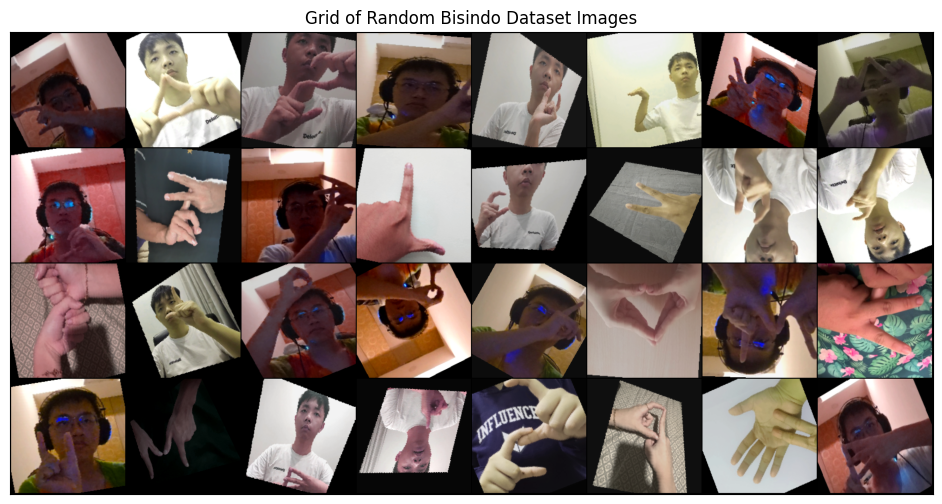

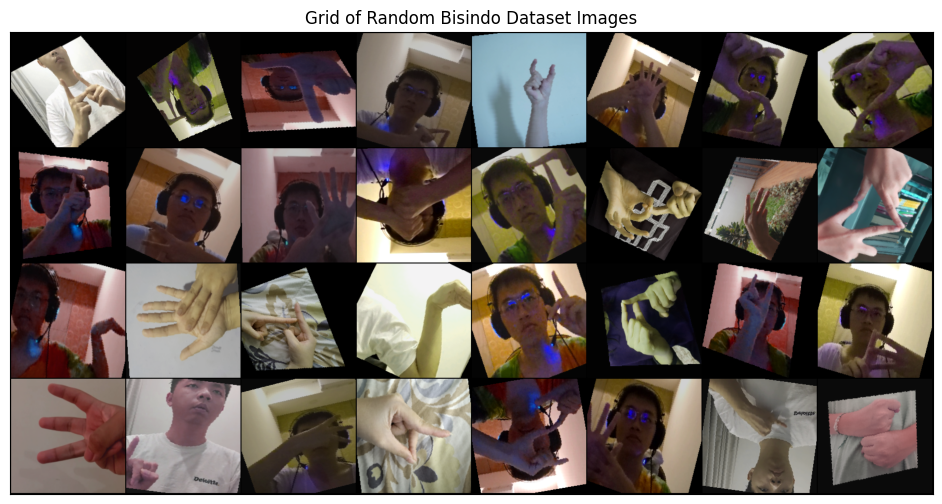

Traceback (most recent call last):
  File "/home/web-scientia/miniconda3/envs/devan_ths/lib/python3.9/multiprocessing/util.py", line 300, in _run_finalizers
    finalizer()
  File "/home/web-scientia/miniconda3/envs/devan_ths/lib/python3.9/multiprocessing/util.py", line 224, in __call__
    res = self._callback(*self._args, **self._kwargs)
  File "/home/web-scientia/miniconda3/envs/devan_ths/lib/python3.9/multiprocessing/util.py", line 133, in _remove_temp_dir
    rmtree(tempdir)
  File "/home/web-scientia/miniconda3/envs/devan_ths/lib/python3.9/shutil.py", line 740, in rmtree
    onerror(os.rmdir, path, sys.exc_info())
  File "/home/web-scientia/miniconda3/envs/devan_ths/lib/python3.9/shutil.py", line 738, in rmtree
    os.rmdir(path)
OSError: [Errno 39] Directory not empty: '/tmp/pymp-mh78yvjo'


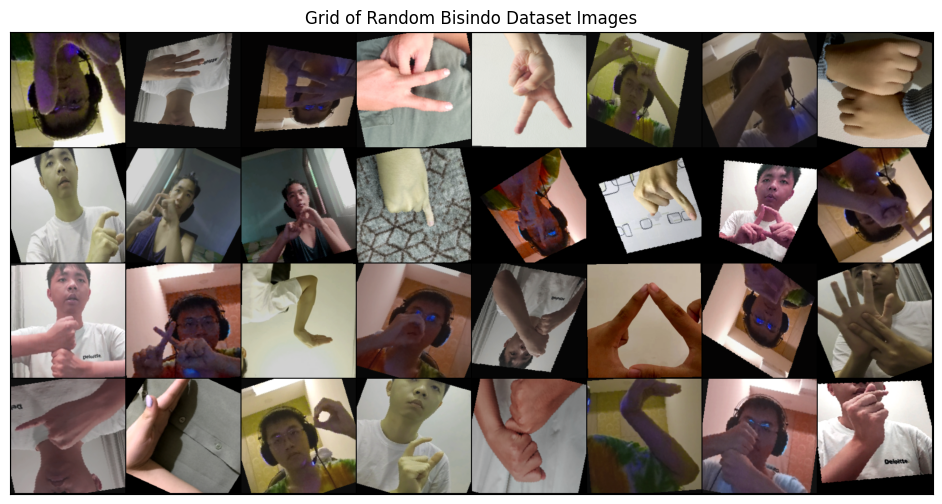

In [12]:
import matplotlib.pyplot as plt
import torchvision.utils as utils

mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]

def denormalize(img_tensor, mean, std):
    for t, m, s in zip(img_tensor, mean, std):
        t.mul_(s).add_(m)  # Reverse normalization
    return img_tensor

def plot_random_grid_images()->None:
    images, labels = next(iter(train_loader_aug))
    images_denorm = torch.stack([denormalize(img.clone(), mean, std) for img in images])
    grid_tensor = utils.make_grid(images_denorm, nrow=8).permute(1, 2, 0)  # Change to HWC for plt.imshow
    plt.figure(figsize=(12, 6))  # Adjust size as needed
    plt.imshow(grid_tensor.numpy())
    plt.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)  # Remove ticks
    plt.title("Grid of Random Bisindo Dataset Images")
    plt.show()

plot_random_grid_images()
plot_random_grid_images()
plot_random_grid_images()

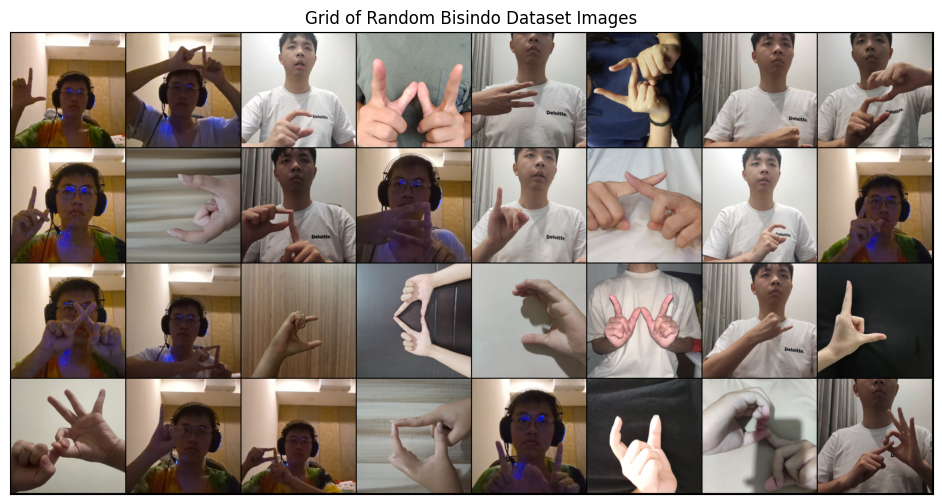

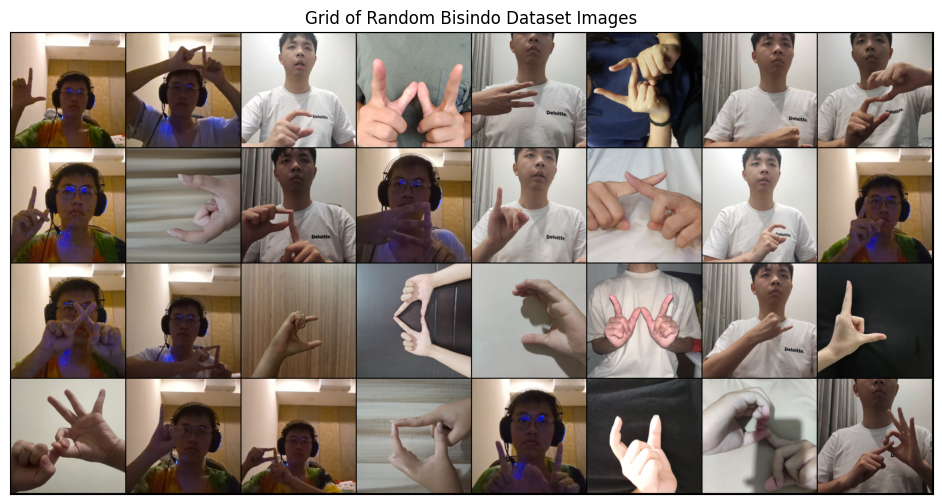

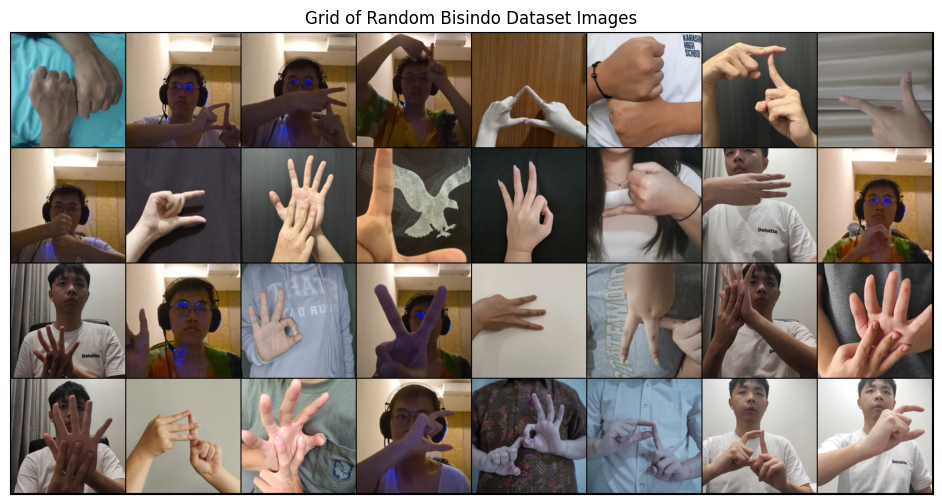

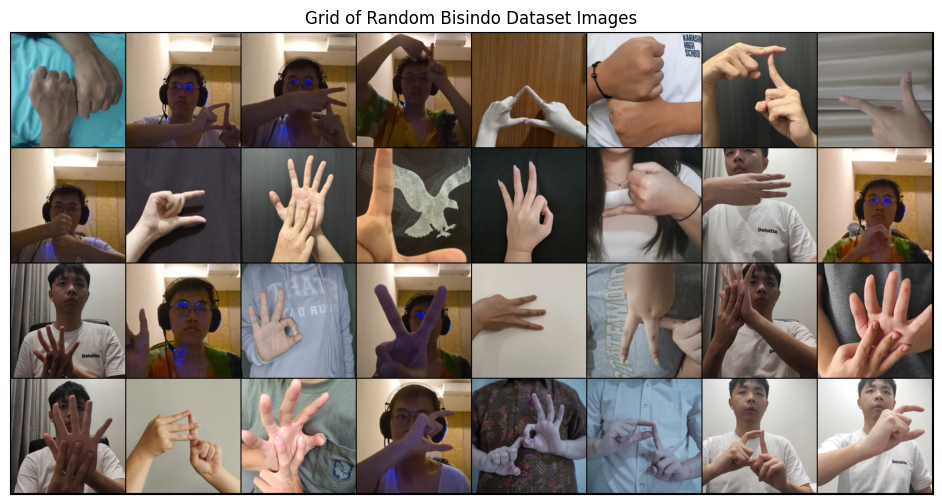

In [13]:
def plot_random_grid_images_validation(dataset:string)->None:
    images, labels = next(iter(dataset))
    images_denorm = torch.stack([denormalize(img.clone(), mean, std) for img in images])
    grid_tensor = utils.make_grid(images_denorm, nrow=8).permute(1, 2, 0)  # Change to HWC for plt.imshow
    plt.figure(figsize=(12, 6))  # Adjust size as needed
    plt.imshow(grid_tensor.numpy())
    plt.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)  # Remove ticks
    plt.title("Grid of Random Bisindo Dataset Images")
    plt.show()

plot_random_grid_images_validation(val_loader_aug)
plot_random_grid_images_validation(val_loader_aug)
plot_random_grid_images_validation(test_loader_aug)
plot_random_grid_images_validation(test_loader_aug)

# **Define the Model Parameters**

To train this model, we will train in 3 epochs, with a batch size of 10 and a learning rate of 2e-5:

# **Initialized Model and Feature Extractor**

In [14]:
vit_small_model = 'ShuffleNetV2'
vit_base_model = 'EfficientNetB5'
# pretrained_model_name = 'models/ConvNeXt-pytorch.pth'
pretrained_model_name = 'models/EfficientNetB5-pytorch.pth'

In [15]:
from torch import nn
import transformers, timm
from torchvision import models as Models
from torchvision.models import ShuffleNet_V2_X1_5_Weights
from transformers.modeling_outputs import ImageClassifierOutput, ImageClassifierOutputWithNoAttention

class ShuffleNetV2ForImageClassification(nn.Module):
    def __init__(self, num_classes:int, model_name:string) -> None:
        super().__init__()
        self.num_classes = num_classes
        model = Models.shufflenet_v2_x1_5(weights=ShuffleNet_V2_X1_5_Weights.IMAGENET1K_V1)
        self.model = nn.Sequential(*list(model.children())[:-2])
        self.dropout = nn.Dropout(DROPOUT)
        self.pooling = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Linear(704, num_classes)
    
    def forward(self, pixel_values: Optional[torch.Tensor], labels: Optional[torch.Tensor] = None, 
                return_dict: Optional[bool] = None):  
        batch_size, c, w, h = pixel_values.size()
        pixel_values = pixel_values.view(batch_size , c, h, w)
        feature_map = self.model(pixel_values)
        feature_map = self.dropout(self.pooling(feature_map))
        logits = self.classifier(feature_map.view(batch_size, -1))

        if labels is not None:
            loss_function = nn.CrossEntropyLoss()
            loss = loss_function(logits, labels)
        
        return ImageClassifierOutputWithNoAttention(            
            loss=None,
            logits=logits,
            hidden_states=None)

class EfficientNetForImageClassification(nn.Module):
    def __init__(self, num_classes:int, model_name:string) -> None:
        super().__init__()
        self.num_classes = num_classes
        model = timm.create_model('tf_efficientnet_b5.aa_in1k', pretrained=True)
        self.model = nn.Sequential(*list(model.children())[:-2])
        self.dropout = nn.Dropout(DROPOUT)
        self.pooling = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Linear(2048, num_classes)
    
    def forward(self, pixel_values: Optional[torch.Tensor], labels: Optional[torch.Tensor] = None, 
                return_dict: Optional[bool] = None):  
        batch_size, c, w, h = pixel_values.size()
        pixel_values = pixel_values.view(batch_size , c, h, w)
        feature_map = self.model(pixel_values)
        feature_map = self.dropout(self.pooling(feature_map))
        logits = self.classifier(feature_map.view(batch_size, -1))

        if labels is not None:
            loss_function = nn.CrossEntropyLoss()
            loss = loss_function(logits, labels)
        
        return ImageClassifierOutputWithNoAttention(            
            loss=None,
            logits=logits,
            hidden_states=None)

/home/web-scientia/miniconda3/envs/devan_ths/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [16]:
student_model = ShuffleNetV2ForImageClassification(num_classes,vit_small_model)
teacher_model = EfficientNetForImageClassification(num_classes,vit_base_model)
teacher_model.load_state_dict(torch.load(pretrained_model_name))
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
optimizer = torch.optim.AdamW(student_model.parameters(), lr=LEARNING_RATE, weight_decay = WEIGHT_DECAY)
criterion = nn.CrossEntropyLoss().to(device)

/tmp/ipykernel_175857/234142997.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  teacher_model.load_state_dict(torch.load(pretrained_model_name))


In [17]:
student_model.to(device)

ShuffleNetV2ForImageClassification(
  (model): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (1): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (2): Sequential(
      (0): InvertedResidual(
        (branch1): Sequential(
          (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=24, bias=False)
          (1): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): Conv2d(24, 88, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (3): BatchNorm2d(88, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (4): ReLU(inplace=True)
        )
        (branch2): Sequential(
          (0): Conv2d(24, 88, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): Ba

In [18]:
teacher_model.to(device)

EfficientNetForImageClassification(
  (model): Sequential(
    (0): Conv2dSame(3, 48, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (1): BatchNormAct2d(
      48, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
      (drop): Identity()
      (act): SiLU(inplace=True)
    )
    (2): Sequential(
      (0): Sequential(
        (0): DepthwiseSeparableConv(
          (conv_dw): Conv2d(48, 48, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=48, bias=False)
          (bn1): BatchNormAct2d(
            48, eps=0.001, momentum=0.1, affine=True, track_running_stats=True
            (drop): Identity()
            (act): SiLU(inplace=True)
          )
          (aa): Identity()
          (se): SqueezeExcite(
            (conv_reduce): Conv2d(48, 12, kernel_size=(1, 1), stride=(1, 1))
            (act1): SiLU(inplace=True)
            (conv_expand): Conv2d(12, 48, kernel_size=(1, 1), stride=(1, 1))
            (gate): Sigmoid()
          )
          (conv_pw): Conv2d(4

In [19]:
pytorch_total_params_s = sum(p.numel() for p in student_model.parameters())
pytorch_total_params_t = sum(p.numel() for p in teacher_model.parameters())
print(f'Number of Parameters present in Student Model: {pytorch_total_params_s}')
print(f'Number of Parameters present in Teacher Model: {pytorch_total_params_t}')

Number of Parameters present in Student Model: 1774010
Number of Parameters present in Teacher Model: 28394058


In [20]:
print(torch.cuda.memory_summary(device=torch.cuda.current_device()))
print("Allocated Memory: ", torch.cuda.memory_allocated()/1e6, "MB")
print("Cahced Memory: ", torch.cuda.memory_reserved()/1e6, "MB")

|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 0            |        cudaMalloc retries: 0         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      | 120225 KiB | 120225 KiB | 233350 KiB | 113125 KiB |
|       from large pool |  77888 KiB |  77888 KiB | 155776 KiB |  77888 KiB |
|       from small pool |  42337 KiB |  42337 KiB |  77574 KiB |  35237 KiB |
|---------------------------------------------------------------------------|
| Active memory         | 120225 KiB | 120225 KiB | 233350 KiB | 113125 KiB |
|       from large pool |  77888 KiB |  77888 KiB | 155776 KiB |

In [21]:
# del(teacher_model)
# del(student_model)

# **Train the Model**

In [22]:
class averageMeter(object):
    def __init__(self):
        self.reset()
    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count

def calculate_accuracy(outputs, targets):
    batch_size = targets.size(0)
    _, pred = outputs.topk(1, dim=1, largest=True, sorted=True)
    pred = pred.t() 
    correct = pred.eq(targets.view(1, -1))
    n_correct_elems = correct.float().sum().item()
    return 100* n_correct_elems / batch_size

In [23]:
def plot_loss(train_loss_avg,test_loss_avg,num_epochs):
  Loss_Training = train_loss_avg
  Loss_Value = test_loss_avg
  print(num_epochs)
  epochs = range(1,num_epochs+1)
  plt.plot(epochs, Loss_Training, 'g', label='Training loss')
  plt.plot(epochs, Loss_Value, 'b', label='validation loss')
  plt.title('Training and Validation loss')
  plt.xlabel('Epochs')
  plt.ylabel('Loss')
  plt.legend()
  plt.show()
def plot_accuracy(train_accuracy,test_accuracy,num_epochs):
  Loss_Training = train_accuracy
  Loss_Value = test_accuracy
  epochs = range(1,num_epochs+1)
  plt.plot(epochs, Loss_Training, 'g', label='Training accuracy')
  plt.plot(epochs, Loss_Value, 'b', label='validation accuracy')
  plt.title('Training and Validation accuracy')
  plt.xlabel('Epochs')
  plt.ylabel('Accuracy')
  plt.legend()
  plt.show()

In [24]:
losses_training = []
losses_validation = []
accuracy_traning = []
accuracy_validation = []

In [25]:
start_time = time.time()
for epoch in range(EPOCHS):
    student_model.train()
    teacher_model.eval()
    current_average_loss_training = averageMeter()
    current_average_accuracy_training = averageMeter()

    for i, (inputs, labels) in enumerate(train_loader_aug):
        if torch.cuda.is_available(): inputs, labels = inputs.to(device), labels.to(device).type(torch.cuda.LongTensor)
        else: inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        with torch.no_grad(): teacher_outputs = teacher_model(inputs)
        student_outputs = student_model(inputs)
        soft_targets = nn.functional.softmax(teacher_outputs.logits/TEMPERATURE, dim=1)
        soft_prob = nn.functional.log_softmax(student_outputs.logits/TEMPERATURE, dim=1)
        soft_targets_loss = nn.functional.kl_div(soft_prob, soft_targets, reduction="none").sum(1).mean()*(TEMPERATURE**2)
        hard_targets_loss = criterion(student_outputs.logits, labels)
        loss = TEACHER_LOSS_CONF * soft_targets_loss + STUDENT_LOSS_CONF * hard_targets_loss
        current_epoch_accuracy = calculate_accuracy(student_outputs.logits, labels)
        current_average_loss_training.update(loss.item(), inputs.size(0))
        current_average_accuracy_training.update(current_epoch_accuracy, inputs.size(0))
        loss.backward()
        optimizer.step()
        sys.stdout.write(
            "\r[Epoch %d/%d] [Batch %d / %d] [Loss: %f, Acc: %.2f%%]"
            % (
                epoch,
                EPOCHS,
                i,
                len(train_loader_aug),
                current_average_loss_training.avg,
                current_average_accuracy_training.avg)
        )
    print(" ")
    torch.save(student_model.state_dict(),'checkpoint.pt')
    losses_training.append(current_average_loss_training.avg)
    accuracy_traning.append(current_average_accuracy_training.avg)

    student_model.eval()
    avarage_loss_validation = averageMeter()
    avarage_accuracy_validation = averageMeter()
    prediction = []
    ground_truth = []
    with torch.no_grad():
        for i, (inputs, labels) in enumerate(val_loader_aug):
            if torch.cuda.is_available(): inputs, labels = inputs.to(device), labels.to(device).type(torch.cuda.LongTensor)
            else: inputs.to(device), labels.to(device)
            outputs = student_model(inputs)
            validation_losses = torch.mean(criterion(outputs.logits, labels))
            validation_accuracy = calculate_accuracy(outputs.logits, labels)
            _, predicted = torch.max(outputs.logits, 1)

            ground_truth += labels.detach().cpu().numpy().reshape(len(labels)).tolist()
            prediction += predicted.detach().cpu().numpy().reshape(len(predicted)).tolist()
            avarage_loss_validation.update(validation_losses.item(), inputs.size(0))
            avarage_accuracy_validation.update(validation_accuracy, inputs.size(0))
            sys.stdout.write(
                    "\r[Batch %d / %d]  [Loss: %f, Acc: %.2f%%]"
                    % (
                        i,
                        len(val_loader_aug),
                        avarage_loss_validation.avg,
                        avarage_accuracy_validation.avg
                    )
            )
        print(" ")
    losses_validation.append(avarage_loss_validation.avg)
    accuracy_validation.append(avarage_accuracy_validation.avg)
end_time = time.time()
total_time_seconds = end_time - start_time
hours = total_time_seconds // 3600
minutes = (total_time_seconds % 3600) // 60
seconds = total_time_seconds % 60
print(f'Total training time for current model took around {int(hours)}h {int(minutes)}m {seconds:.2f}s')

[Epoch 0/50] [Batch 288 / 289] [Loss: 6.258432, Acc: 4.14%] 
[Batch 72 / 73]  [Loss: 3.255500, Acc: 8.11%] 
[Epoch 1/50] [Batch 288 / 289] [Loss: 6.118993, Acc: 5.43%] 
[Batch 72 / 73]  [Loss: 3.169707, Acc: 11.67%] 
[Epoch 2/50] [Batch 288 / 289] [Loss: 6.032474, Acc: 7.55%] 
[Batch 72 / 73]  [Loss: 3.102674, Acc: 16.83%] 
[Epoch 3/50] [Batch 288 / 289] [Loss: 5.956029, Acc: 9.69%] 
[Batch 72 / 73]  [Loss: 3.022914, Acc: 20.69%] 
[Epoch 4/50] [Batch 288 / 289] [Loss: 5.857064, Acc: 12.58%] 
[Batch 72 / 73]  [Loss: 2.943616, Acc: 25.21%] 
[Epoch 5/50] [Batch 288 / 289] [Loss: 5.741542, Acc: 16.23%] 
[Batch 72 / 73]  [Loss: 2.836160, Acc: 29.46%] 
[Epoch 6/50] [Batch 288 / 289] [Loss: 5.616242, Acc: 20.08%] 
[Batch 72 / 73]  [Loss: 2.715908, Acc: 33.36%] 
[Epoch 7/50] [Batch 288 / 289] [Loss: 5.467612, Acc: 23.25%] 
[Batch 72 / 73]  [Loss: 2.584068, Acc: 37.96%] 
[Epoch 8/50] [Batch 288 / 289] [Loss: 5.289559, Acc: 27.53%] 
[Batch 72 / 73]  [Loss: 2.443641, Acc: 42.21%] 
[Epoch 9/50] [B

In [26]:
sorted_accuracy_traning = sorted(accuracy_traning)
sorted_losses_training = sorted(losses_training)
sorted_accuracy_validation = sorted(accuracy_validation)
sorted_losses_validation = sorted(losses_validation)
print(f"=========================================================================")
print(f"Total Training Accuracy: {sum(accuracy_traning)/len(accuracy_traning)}%")
print(f"Total Training Loss: {sum(losses_training)/len(losses_training)}%")
print(f"=========================================================================")
print(f"Best Training Accuracy: {sorted_accuracy_traning[-1]}%")
print(f"Best Training Loss: {sorted_losses_training[0]}%") 
print(f"=========================================================================")
print(f"Total Validation Accuracy: {sum(accuracy_validation)/len(accuracy_validation)}%")
print(f"Total Validation Loss: {sum(losses_validation)/len(losses_validation)}%")
print(f"=========================================================================")
print(f"Best Validation Accuracy: {sorted_accuracy_validation[-1]}%")
print(f"Best Validation Loss: {sorted_losses_validation[0]}%") 
print(f"=========================================================================")

Total Training Accuracy: 54.82568608308927%
Total Training Loss: 3.196489362371681%
Best Training Accuracy: 81.5706692699859%
Best Training Loss: 1.294606451952531%
Total Validation Accuracy: 64.37483731019523%
Total Validation Loss: 1.3194214546164564%
Best Validation Accuracy: 86.941431670282%
Best Validation Loss: 0.4289266508193828%


50


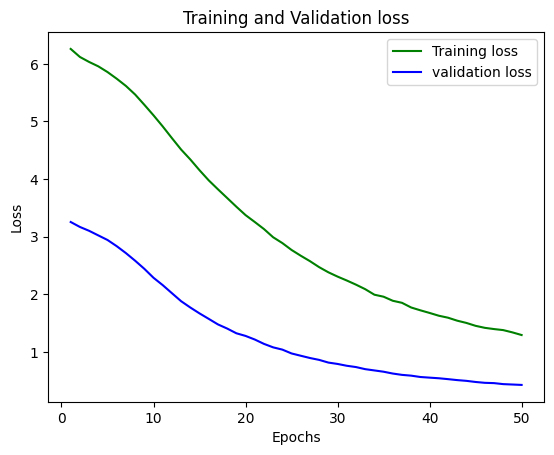

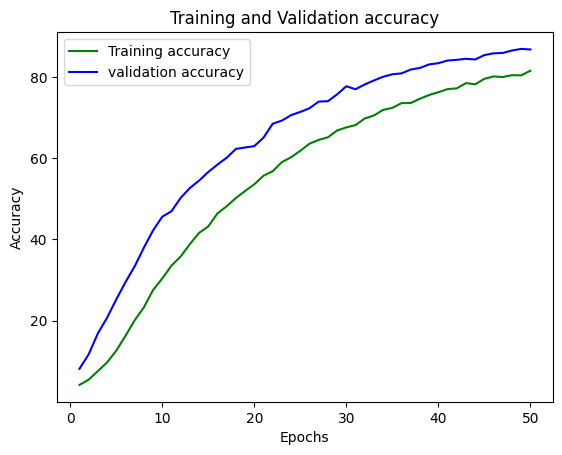

[[104   0   0   3   0   0   0   3   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0]
 [  0 106   0   1   0   0   0   0   0   0   0   0   0   0   0   1   1   0
    0   0   0   0   0   0   0   0]
 [  0   0  70   0   0   0   0   0   0   0   0   2   0   0   1   0   1   2
    0   0   3   0   0   0   1   3]
 [  1   0   0  72   0   0   0   0   0   0   1   0   0   0   0  10   3   0
    1   0   0   0   0   0   0   0]
 [  0   1   0   1  86   2   0   0   1   0   0   0   0   0   0   0   0   0
    0   0   0   1   0   0   0   0]
 [  0   3   0   0   0  91   0   2   0   0   0   0   0   0   0   0   0   0
    1   1   0   0   0   1   0   0]
 [  0   0   1   0   0   0  94   0   0   1   1   0   0   0   0   0   0   0
    1   0   0   0   0   0   0   0]
 [  0   0   0   1   0   4   0  76   0   0   0   1   0   0   0   1   0   0
    1   2   1   0   0   0   0   0]
 [  0   0   2   1   0   0   0   0  74   1   1   0   0   0   1   0   0   0
    0   0   2   0   0   0   0   1]
 [  0   0   2   0  

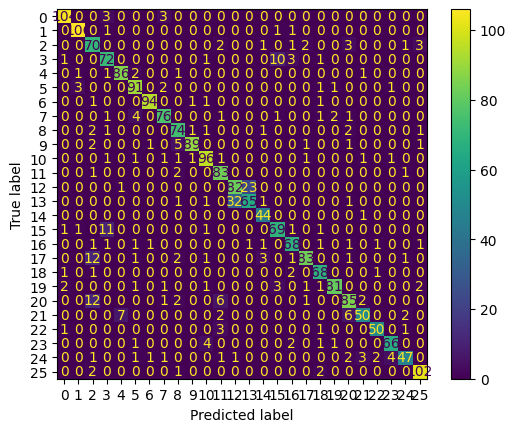

In [27]:
from sklearn.metrics import ConfusionMatrixDisplay
plot_loss(losses_training,losses_validation,len(losses_training))
plot_accuracy(accuracy_traning,accuracy_validation,len(accuracy_traning))
cm = confusion_matrix(ground_truth,prediction)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
print(cm)
disp.plot()
plt.show()

In [28]:
classification_report_table = classification_report(ground_truth, prediction, output_dict=True)
classification_report_dataframe = pd.DataFrame(classification_report_table).transpose()
classification_report_dataframe

,precision,recall,f1-score,support
0,0.945455,0.945455,0.945455,110.000000
1,0.954955,0.972477,0.963636,109.000000
2,0.666667,0.843373,0.744681,83.000000
3,0.782609,0.818182,0.800000,88.000000
4,0.914894,0.934783,0.924731,92.000000
5,0.883495,0.919192,0.900990,99.000000
6,0.969072,0.959184,0.964103,98.000000
7,0.894118,0.873563,0.883721,87.000000
8,0.831461,0.891566,0.860465,83.000000
9,0.967391,0.890000,0.927083,100.000000


In [29]:
torch.save(student_model.state_dict(), 'models/ShuffleNetV2-KD-pytorch.pth')

In [30]:
student_model.eval()
avarage_accuracy_testing = averageMeter()
prediction = []
ground_truth = []
with torch.no_grad():
    for i, (inputs, labels) in enumerate(test_loader_aug):
        if torch.cuda.is_available(): inputs, labels = inputs.to(device), labels.to(device).type(torch.cuda.LongTensor)
        else: inputs.to(device), labels.to(device)
        outputs = student_model(inputs)
        testing_accuracy = calculate_accuracy(outputs.logits, labels)
        _, predicted = torch.max(outputs.logits, 1)
        ground_truth += labels.detach().cpu().numpy().reshape(len(labels)).tolist()
        prediction += predicted.detach().cpu().numpy().reshape(len(predicted)).tolist()
        avarage_accuracy_testing.update(testing_accuracy, inputs.size(0))
    print(f"Total Testing Accuracy: {avarage_accuracy_testing.avg}%")


Total Testing Accuracy: 87.92505204718945%


[[105   0   0   1   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0   0   0   0]
 [  1 113   0   0   0   2   0   0   0   0   1   0   0   0   0   1   1   0
    0   1   0   0   0   0   0   0]
 [  0   0 120   0   0   0   0   0   0   0   0   0   0   0   1   0   0   1
    0   0   2   0   0   0   1   3]
 [  0   0   0 123   0   0   0   1   0   0   2   0   0   0   0  13   0   0
    0   0   0   0   0   0   0   0]
 [  0   3   0   0 111   3   0   0   0   1   0   0   0   0   0   0   0   0
    2   0   0   3   0   0   0   1]
 [  0   2   0   0   0  96   0   3   0   0   2   1   0   0   1   0   0   0
    0   0   0   1   0   0   0   0]
 [  0   0   1   0   0   0 113   0   0   1   2   0   0   0   0   0   0   0
    2   0   0   0   0   0   0   3]
 [  0   0   0   2   0   0   0 103   4   0   0   0   0   0   0   0   0   0
    0   5   0   0   1   0   1   0]
 [  0   0   0   0   0   0   2   0 106   6   0   1   0   0   0   0   0   0
    0   0   0   0   0   0   0   0]
 [  0   0   1   0  

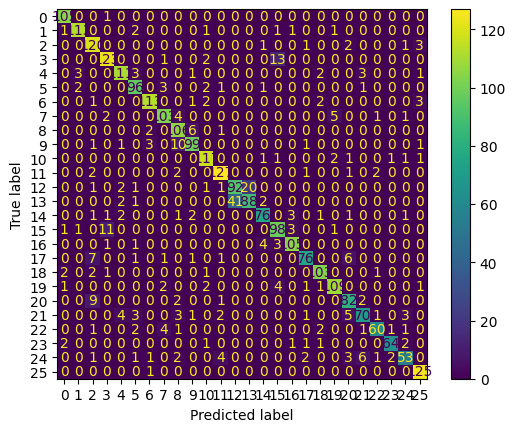

In [31]:
cm = confusion_matrix(ground_truth,prediction)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
print(cm)
disp.plot()
plt.show()

In [32]:
classification_report_table = classification_report(ground_truth, prediction, output_dict=True)
classification_report_dataframe = pd.DataFrame(classification_report_table).transpose()
classification_report_dataframe

,precision,recall,f1-score,support
0,0.937500,0.990566,0.963303,106.000000
1,0.949580,0.941667,0.945607,120.000000
2,0.821918,0.937500,0.875912,128.000000
3,0.878571,0.884892,0.881720,139.000000
4,0.909836,0.895161,0.902439,124.000000
5,0.864865,0.905660,0.884793,106.000000
6,0.941667,0.926230,0.933884,122.000000
7,0.903509,0.887931,0.895652,116.000000
8,0.809160,0.921739,0.861789,115.000000
9,0.891892,0.853448,0.872247,116.000000
